## Data Preparation
## CRISP-DM – Fase 3

<hr>

## Objetivos desta fase

Preparar os dados para a fase de modelação, seguindo as boas práticas de machine learning:

- Evitar **data leakage** em todas as transformações
- Criar **conjuntos de features** para comparação de desempenho
- Aplicar **One-Hot Encoding** e **scaling** de forma controlada
- Garantir reprodutibilidade (stratified split, random_state fixo)
- Exportar dados prontos para Modeling (Fase 4)

**Decisões principais herdadas da Fase 2:**
- Manter todas as variáveis originais
- Priorizar feature engineering para capturar interações não-lineares
- Usar modelos não-lineares como alvo principal → as features devem facilitar a captura de interações

<br>
<hr>

## 0. Importação de bibliotecas e definição de paths

Importamos as bibliotecas necessárias e definimos os caminhos do projeto de forma consistente.

In [1]:
# Importação das libraries

import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Paths do projeto

BASE_DIR = Path().resolve()

DATA_DIR = BASE_DIR / "data"
DATA_PREPARED_DIR = DATA_DIR / "prepared"

OUTPUTS_DIR = BASE_DIR / "outputs"
FIGURES_BASE_DIR = OUTPUTS_DIR / "figures"

FIGURES_UNDERSTANDING_DIR = FIGURES_BASE_DIR / "understanding"
FIGURES_PREPARATION_DIR = FIGURES_BASE_DIR / "preparation"
FIGURES_MODELING_DIR = FIGURES_BASE_DIR / "modeling"

# Criar pastas automaticamente
DATA_PREPARED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_UNDERSTANDING_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_MODELING_DIR.mkdir(parents=True, exist_ok=True)

<hr>

## 1. Carregamento e preparação inicial do dataset

Carregamos o ficheiro raw e criamos uma cópia de trabalho (df).

**Porquê?**  
Preservar o dataset original inalterado e trabalhar de forma controlada em todas as transformações subsequentes.

In [2]:
# Carregar o dataset
DATASET_PATH = BASE_DIR / "HR-Intern-Retention_Dataset.csv"
df_raw = pd.read_csv(DATASET_PATH).drop(columns=["Intern_ID"], errors="ignore")

# Criamos uma cópia para trabalhar (boa prática)
df = df_raw.copy()

print(f"Dataset original carregado: {df_raw.shape}")
print(f"Cópia de trabalho criada: {df.shape}")

Dataset original carregado: (200, 8)
Cópia de trabalho criada: (200, 8)


## 2. Feature Engineering

Criamos novas variáveis **no dataset completo**.

**Objetivo:**  
Capturar os padrões críticos da Fase 2:
- Perfis de elite e risco de churn em IT/Finance
- Efeito não-linear da duração do estágio
- Relações relativas de salário e desempenho

Features criadas:
- `Is_Top_Performer` (elite por avaliação e assiduidade)

- `Risky_Department`, `Top_in_Risky_Dep`, `Top_in_Risky_Dep_Smooth` (churn crítico)

- `Duration_Bin` (fases do estágio)

- `Salary_Per_Month`, `Performance_Ratio`, `Salary_vs_Major_Diff`, `Low_Eval_High_Attendance` (ratios e desalinhamentos)
<br>

> Nota: Para evitar Data Leakage (evitar que o modelo "veja" os dados de teste) e preservar o valor informacional das variáveis, a feature engineering deve ser feita antes do scaling, que deve ser ajustado apenas no conjunto de treino.

In [3]:
# Features adicionais

# 1. Is_Top_Performer (fase 2)
df['Is_Top_Performer'] = (
    (df['Supervisor_Evaluation'] >= df_raw['Supervisor_Evaluation'].quantile(0.75)) & 
    (df['Attendance_%'] >= df_raw['Attendance_%'].quantile(0.75))
).astype(int)

# 2. Features básicas
df['Salary_Per_Month'] = df['Salary'] / df['Internship_Duration_Months']
df['Performance_Ratio'] = df['Supervisor_Evaluation'] / (df['Salary'] / 1000)
major_avg = df.groupby('Major')['Salary'].transform('mean')
df['Salary_vs_Major_Diff'] = df['Salary'] - major_avg
df['Low_Eval_High_Attendance'] = ((df['Supervisor_Evaluation'] < df_raw['Supervisor_Evaluation'].quantile(0.25)) & (df['Attendance_%'] > df_raw['Attendance_%'].quantile(0.75))).astype(int)

# 3. Features avançadas
df['Risky_Department'] = df['Department'].isin(['IT', 'Finance']).astype(int)

df['Top_in_Risky_Dep'] = (df['Is_Top_Performer'] * df['Risky_Department']).astype(int)

df['Top_in_Risky_Dep_Smooth'] = df['Top_in_Risky_Dep'] * df['Supervisor_Evaluation'] / 5.0      # transformação da feature 'Top_in_Risky_Dep' para reduzir o efeito extremo - melhorou o modelo na fase seguinte

df['Duration_Bin'] = pd.cut(df['Internship_Duration_Months'], bins=[0, 6, 12, 18, 24], labels=['Curta', 'Média', 'Longa', 'Muito_Longa'])

print("Todas as features criadas com sucesso.")

df

Todas as features criadas com sucesso.


,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained,Is_Top_Performer,Salary_Per_Month,Performance_Ratio,Salary_vs_Major_Diff,Low_Eval_High_Attendance,Risky_Department,Top_in_Risky_Dep,Top_in_Risky_Dep_Smooth,Duration_Bin
0,24,IT,20,Legal,1.8,1956,71.9,1,0,97.800000,0.920245,539.173913,0,0,0,0.00,Muito_Longa
1,21,Law,15,HR,1.2,1687,82.7,0,0,112.466667,0.711322,294.439024,0,0,0,0.00,Longa
2,28,Engineering,3,HR,1.7,926,79.0,0,0,308.666667,1.835853,-489.387755,0,0,0,0.00,Curta
3,25,IT,23,Marketing,2.1,1929,86.5,1,0,83.869565,1.088647,512.173913,0,0,0,0.00,Muito_Longa
4,22,Engineering,8,Legal,1.7,1808,97.5,1,0,226.000000,0.940265,392.612245,1,0,0,0.00,Média
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,26,IT,8,Finance,3.4,948,73.4,1,0,118.500000,3.586498,-468.826087,0,1,0,0.00,Média
196,22,IT,16,Finance,1.1,810,89.7,1,0,50.625000,1.358025,-606.826087,0,1,0,0.00,Longa
197,18,Marketing,13,Marketing,4.5,1475,66.4,1,0,113.461538,3.050847,33.206897,0,0,0,0.00,Longa
198,20,IT,1,IT,4.7,1936,92.7,0,1,1936.000000,2.427686,519.173913,0,1,1,0.94,Curta


<hr>

## 3. One-Hot Encoding

Aplicamos One-Hot Encoding às variáveis categóricas (`Major`, `Department`, `Duration_Bin`).

**Porquê?**  
Evitar introduzir ordem artificial em variáveis sem hierarquia.  
Garantir compatibilidade com modelos que não lidam nativamente com categorias (embora árvores lidem bem, é boa prática para consistência).

In [4]:
# One-Hot Encoding

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[['Major', 'Department', 'Duration_Bin']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Major', 'Department', 'Duration_Bin']),
    index=df.index
)

df_onehot = pd.concat([df.drop(['Major', 'Department', 'Duration_Bin'], axis=1), encoded_df], axis=1)

df_onehot

,Age,Internship_Duration_Months,Supervisor_Evaluation,Salary,Attendance_%,Retained,Is_Top_Performer,Salary_Per_Month,Performance_Ratio,Salary_vs_Major_Diff,...,Major_Marketing,Department_Finance,Department_HR,Department_IT,Department_Legal,Department_Marketing,Duration_Bin_Curta,Duration_Bin_Longa,Duration_Bin_Muito_Longa,Duration_Bin_Média
0,24,20,1.8,1956,71.9,1,0,97.800000,0.920245,539.173913,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,21,15,1.2,1687,82.7,0,0,112.466667,0.711322,294.439024,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,28,3,1.7,926,79.0,0,0,308.666667,1.835853,-489.387755,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,25,23,2.1,1929,86.5,1,0,83.869565,1.088647,512.173913,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,22,8,1.7,1808,97.5,1,0,226.000000,0.940265,392.612245,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,26,8,3.4,948,73.4,1,0,118.500000,3.586498,-468.826087,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
196,22,16,1.1,810,89.7,1,0,50.625000,1.358025,-606.826087,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
197,18,13,4.5,1475,66.4,1,0,113.461538,3.050847,33.206897,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
198,20,1,4.7,1936,92.7,0,1,1936.000000,2.427686,519.173913,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


### Validação das features criadas

Após o feature engineering, analisámos novamente a correlação de cada variável com a target `Retained`.

**Objetivo:**  
Perceber se as novas variáveis criadas estavam, de facto, a captar algum sinal relevante para a retenção — ou se eram apenas ruído.

**O que observamos:**
- As variáveis com maior relação com a retenção continuam a ser relativamente fracas (nenhuma ultrapassa ~0.25), mas ainda assim comnseguimos alcançar relações mais fortes do que antes de aplicarmos feature engineering. Concluimos novamente que o problema não é linear.
- Algumas das features criadas surgem entre as variáveis com maior correlação com a target, indicando que o feature engineering conseguiu captar sinal adicional que não estava explícito nas variáveis originais.

**Conclusão:**  
O feature engineering acrescentou algumas variáveis úteis, mas não introduziu relações fortes com a target. Isto sugere novamente que:
- A retenção depende de múltiplos fatores combinados
- Será necessário recorrer a modelos que captem interações e não linearidades

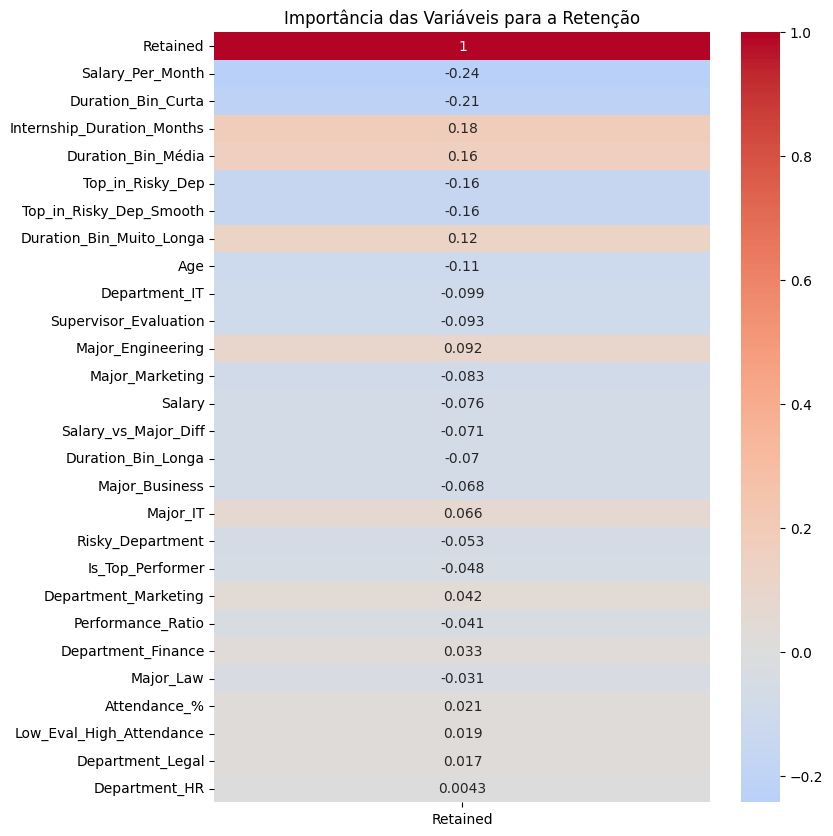

In [5]:
# Calcular correlações
corr_matrix = df_onehot.corr()[['Retained']]

# Criar uma coluna temporária com o valor absoluto para ordenar
corr_matrix['abs_corr'] = corr_matrix['Retained'].abs()

# Ordenar pelo valor absoluto (do mais forte para o mais fraco)
salary_corr_sorted = corr_matrix.sort_values(by='abs_corr', ascending=False).drop('abs_corr', axis=1)

# Plot
plt.figure(figsize=(8, 10))
sns.heatmap(salary_corr_sorted, annot=True, cmap='coolwarm', center=0)
plt.title('Importância das Variáveis para a Retenção')

plt.savefig(FIGURES_PREPARATION_DIR / "importancia_variaveis_retencao.png", bbox_inches="tight")
plt.show()

<hr>

## 4. Criação das versões de features

Definimos três conjuntos progressivos para comparação justa:

- **Versão A - Baseline**: variáveis originais + dummies do One-Hot (sem feature engineering adicional)
- **Versão B - Básica**: baseline + features simples (ratios, Is_Top_Performer, Low_Eval_High_Attendance)
- **Versão C - Avançada**: baseline + interações de risco (Top_in_Risky_Dep_Smooth, Risky_Department) e Duration_Bin 
- **Versão C - Avançada**: todas as anteriores

**Objetivo:**  
Avaliar o impacto do feature engineering no desempenho dos modelos na Fase 4.

In [7]:
# Versão A - Baseline (só originais + One-Hot de Major/Department)
cols_orig = ['Age', 'Internship_Duration_Months', 'Supervisor_Evaluation', 'Salary', 'Attendance_%'] + [col for col in df_onehot.columns if col.startswith(('Major_', 'Department_'))]
X_A = df_onehot[cols_orig].copy()

# Versão B - Básica (originais + 5 features simples)
cols_basic = cols_orig + ['Is_Top_Performer', 'Salary_Per_Month', 'Performance_Ratio', 'Salary_vs_Major_Diff', 'Low_Eval_High_Attendance']
X_B = df_onehot[cols_basic].copy()

# Versão C - Avançada (originais + 3 features avançadas: Risky_Department, Top_in_Risky_Dep e o grupo de Duration_Bin)
cols_advanced = cols_orig + ['Risky_Department', 'Top_in_Risky_Dep_Smooth'] + [col for col in df_onehot.columns if col.startswith('Duration_Bin_')]
X_C = df_onehot[cols_advanced].copy()

#cols_advanced = (
#    [col for col in cols_orig if col != 'Internship_Duration_Months'] +   # remove a redundante   -> Não resultou apenas melhorou recall, manter 'Internship_Duration_Months'
#    ['Risky_Department', 'Top_in_Risky_Dep_Smooth'] +
#    [col for col in df_onehot.columns if col.startswith('Duration_Bin_')]
#)
#X_C = df_onehot[cols_advanced].copy()

# Versão D - Full (tudo)
X_D = df_onehot.copy().drop(['Retained'], axis=1)


print(f"Versão A - Baseline: {X_A.shape[1]} features")
print(f"Versão B - Básica:   {X_B.shape[1]} features")
print(f"Versão C - Avançada: {X_C.shape[1]} features")
print(f"Versão D - Full:     {X_D.shape[1]} features")

Versão A - Baseline: 15 features
Versão B - Básica:   20 features
Versão C - Avançada: 21 features
Versão D - Full:     27 features


<hr>

## 5. Split estratificado + Scaling aplicado às versões

Aplicamos split estratificado (80/20) e StandardScaler a cada versão de features.

**Regras anti-leakage:**
- Split primeiro (stratify por Retained)
- Scaling: fit apenas no X_train de cada versão
- Transform aplicado em X_train e X_test

**Porquê?**  
Garantir que o teste reflita dados "não vistos" e que o escalonamento não vaze informação do teste para o treino.

In [8]:
# 1. Definição de Features (X) e Target (y)
y = df_onehot['Retained']

# 2. Função auxiliar para fazer split + scaling de forma consistente
# (Evita repetição de código e garante o mesmo random_state em todas as versões)
def prepare_data(X):
    # Divisão Estratificada (Mantendo a proporção de 61/39)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,          
        random_state=42,        
        stratify=y              
    )
    
    # Só as colunas CONTÍNUAS (não binárias nem dummies)
    continuous_cols = ['Age', 'Internship_Duration_Months', 'Salary', 'Supervisor_Evaluation', 'Attendance_%', 'Salary_Per_Month', 'Performance_Ratio', 'Salary_vs_Major_Diff']
    
    # Filtra apenas as que realmente existem na versão em questão (evita o erro)
    num_cols = [col for col in continuous_cols if col in X.columns]
    
    scaler = StandardScaler()
    
    # Aplicação Isolada (Evita Data Leakage)
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])
    
    return X_train, X_test, y_train, y_test, scaler


# 4. Aplicação da função às 3 versões de features

# Versão A - Baseline
X_train_A, X_test_A, y_train, y_test, scaler_A = prepare_data(X_A)

# Versão B - Básica (originais + 5 features simples)
X_train_B, X_test_B, _, _, scaler_B = prepare_data(X_B)

# Versão C - Avançada (originais + 3 features avançadas)
X_train_C, X_test_C, _, _, scaler_C = prepare_data(X_C)

# Versão D - Full (todas as features)
X_train_D, X_test_D, _, _, scaler_D = prepare_data(X_D)


# 5. Verificação Final das versões

print("✅ Scaling concluído com sucesso nas 4 versões.\n")
print("Verificação Final das versões:\n")

versoes = {
    'A - Baseline':  (X_train_A,  X_test_A,  y_train, y_test, scaler_A),
    'B - Básica':    (X_train_B,  X_test_B,  y_train, y_test, scaler_B),
    'C - Avançada':  (X_train_C,  X_test_C,  y_train, y_test, scaler_C),
    'D - Full':      (X_train_D,  X_test_D,  y_train, y_test, scaler_D)
}

for nome, (X_train, X_test, y_train_, y_test_, scaler) in versoes.items():
    print(f"\n{nome}")
    print("-" * (len(nome) + 10))
    
    # 1. Shape das matrizes
    print(f"Shape treino: {X_train.shape}")
    print(f"Shape teste:  {X_test.shape}")
    
    # 2. Verificação do scaling (média ~0, std ~1) nas contínuas do treino
    colunas_continuas = [
        col for col in X_train.columns 
        if col in ['Age', 'Internship_Duration_Months', 'Supervisor_Evaluation', 
                   'Salary', 'Attendance_%', 'Salary_Per_Month', 'Performance_Ratio', 
                   'Salary_vs_Major_Diff', 'Top_in_Risky_Dep_Smooth']
    ]
    
    if colunas_continuas:
        medias = X_train[colunas_continuas].mean().round(4)
        desvios = X_train[colunas_continuas].std().round(4)
        
        print("\nMédias no treino (colunas contínuas escalonadas):")
        print(medias.to_string())
        print("\nDesvios-padrão no treino (colunas contínuas escalonadas):")
        print(desvios.to_string())
    else:
        print("\nNenhuma coluna contínua encontrada para verificar scaling.")
    
    # 3. Proporção da target no teste
    prop_teste = y_test_.value_counts(normalize=True).round(3) * 100
    print(f"\nProporção da target no teste (%):")
    print(f"Retained = 1: {prop_teste.get(1, 0):.1f}%")
    print(f"Retained = 0: {prop_teste.get(0, 0):.1f}%")
    
    print("-"*70)

print("\nResumo geral:")
print("• Shapes variam conforme o número de features adicionadas por versão.")
print("• Médias e desvios-padrão devem ser praticamente idênticos entre as 4 versões.")
print("• Proporção da target no teste deve ser ~61% (Retained) / ~39% (Não Retained) em todas as versões.")



# (extra) Amostra da versão principal (C)
print("\nAmostra das primeiras linhas da Versão C (Avançada):")
X_train_C.head()

✅ Scaling concluído com sucesso nas 4 versões.

Verificação Final das versões:


A - Baseline
----------------------
Shape treino: (160, 15)
Shape teste:  (40, 15)

Médias no treino (colunas contínuas escalonadas):
Age                           0.0
Internship_Duration_Months   -0.0
Supervisor_Evaluation         0.0
Salary                       -0.0
Attendance_%                 -0.0

Desvios-padrão no treino (colunas contínuas escalonadas):
Age                           1.0031
Internship_Duration_Months    1.0031
Supervisor_Evaluation         1.0031
Salary                        1.0031
Attendance_%                  1.0031

Proporção da target no teste (%):
Retained = 1: 62.5%
Retained = 0: 37.5%
----------------------------------------------------------------------

B - Básica
--------------------
Shape treino: (160, 20)
Shape teste:  (40, 20)

Médias no treino (colunas contínuas escalonadas):
Age                           0.0
Internship_Duration_Months   -0.0
Supervisor_Evaluation     

,Age,Internship_Duration_Months,Supervisor_Evaluation,Salary,Attendance_%,Major_Business,Major_Engineering,Major_IT,Major_Law,Major_Marketing,...,Department_HR,Department_IT,Department_Legal,Department_Marketing,Risky_Department,Top_in_Risky_Dep_Smooth,Duration_Bin_Curta,Duration_Bin_Longa,Duration_Bin_Muito_Longa,Duration_Bin_Média
195,0.557284,-0.578980,0.396326,-1.347668,-0.706949,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,0.0,1.0
18,-0.600708,0.006403,-1.579692,0.077008,-0.161626,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,1.0
65,0.267786,-1.603398,-0.950959,0.249527,-1.064817,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1,0.0,1.0,0.0,0.0,0.0
51,-0.890207,1.323513,0.037050,0.600130,1.269845,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0
3,0.267786,1.616204,-0.771321,1.382032,0.409258,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,1.0,0.0


**Conclusão do split e scaling:**  
Todas as versões foram divididas e escalonadas corretamente.  
Proporções de Retained mantidas (~61%/39%).  
Valores normalizados (média ≈ 0, desvio padrão ≈ 1) apenas nas contínuas.

<hr>

## 6. Guardar os dados preparados

Exportamos os conjuntos finais para uso direto na Fase 4:

- X_train / X_test para cada versão
- y_train / y_test (comum)

Ficheiros:
- X_train_baseline.csv / X_test_baseline.csv
- X_train_basica.csv / X_test_basica.csv
- X_train_advanced.csv / X_test_advanced.csv
- y_train.csv / y_test.csv

In [9]:
# Guardar Dados Preparados

# Versão A - Baseline
X_train_A.to_csv(DATA_PREPARED_DIR / "X_train_baseline.csv", index=False)
X_test_A.to_csv(DATA_PREPARED_DIR / "X_test_baseline.csv", index=False)

# Versão B - Básica
X_train_B.to_csv(DATA_PREPARED_DIR / "X_train_basica.csv", index=False)
X_test_B.to_csv(DATA_PREPARED_DIR / "X_test_basica.csv", index=False)

# Versão C - Avançada
X_train_C.to_csv(DATA_PREPARED_DIR / "X_train_advanced.csv", index=False)
X_test_C.to_csv(DATA_PREPARED_DIR / "X_test_advanced.csv", index=False)

# Versão D - Full
X_train_D.to_csv(DATA_PREPARED_DIR / "X_train_full.csv", index=False)
X_test_D.to_csv(DATA_PREPARED_DIR / "X_test_full.csv", index=False)

# Targets (iguais para todas as versões)
pd.Series(y_train).to_csv(DATA_PREPARED_DIR / "y_train.csv", index=False)
pd.Series(y_test).to_csv(DATA_PREPARED_DIR / "y_test.csv", index=False)

print("✅ Todos os ficheiros foram guardados com sucesso em data/prepared/")
print("   - X_train_baseline.csv")
print("   - X_train_basica.csv")
print("   - X_train_advanced.csv")
print("   - X_train_full.csv")
print("   - y_train.csv / y_test.csv")

✅ Todos os ficheiros foram guardados com sucesso em data/prepared/
   - X_train_baseline.csv
   - X_train_basica.csv
   - X_train_advanced.csv
   - X_train_full.csv
   - y_train.csv / y_test.csv


<hr>

## Síntese da Fase de Data Preparation

**Principais transformações realizadas:**
- Feature Engineering: criação de variáveis novas (`Is_Top_Performer`, `Salary_Per_Month`, `Performance_Ratio`, `Salary_vs_Major_Diff`, `Low_Eval_High_Attendance`, `Risky_Department`, `Top_in_Risky_Dep`, `Top_in_Risky_Dep_Smooth`, `Duration_Bin`)
- One-Hot Encoding: aplicado em `Major`, `Department` e `Duration_Bin`
- Criação de versões comparáveis (Baseline, Básica, Avançada, Full)
- Data Partitioning: split estratificado (80/20) mantendo proporção da target
- Scaling: aplicação de `StandardScaler` apenas após o split, garantindo zero Data Leakage
- Exportação de ficheiros prontos para modelação